# Inteligencia Artificial 2026 - Lab 03

En este laboratorio vamos a diseñar redes neuronales *fully connected* en la librería `tensorflow.keras` para un problema de clasificación y un problema de regresión.

### Ejercicio 1: Clasificación de Dígitos (Scikit-Learn digits)
Este ejercicio se centra en entender cómo una red neuronal "ve" patrones espaciales aplanados.

**Dataset:** `sklearn.datasets.load_digits()` contiene 1,797 muestras, 64 atributos.
**Objetivo:** Configurar la capa de salida y la función de pérdida para clasificación multiclase (10 dígitos).

In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score

# TensorFlow y Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Input

# Configuración de estilo para gráficas
sns.set_theme(style="whitegrid")

### Ejercicio 1: Clasificación de Dígitos (Scikit-Learn digits)
Este ejercicio se centra en entender cómo una red neuronal "ve" patrones espaciales aplanados.

**Dataset:** `sklearn.datasets.load_digits()` contiene 1,797 muestras, 64 atributos.

**Objetivo:** Configurar la capa de salida y la función de pérdida para clasificación multiclase (10 dígitos).

**Instrucciones:**
* Normalizar los datos dividiendo por 16 (el valor máximo de los píxeles). Debe explicar las transformaciones que se están haciendo tanto al conjunto de datos, como a las etiquetas.

In [18]:
# 1. Carga de datos
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# 2. Partición de datos (Train/Test)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42, stratify=y_digits
)

# 3. Normalización de los datos de entrada
X_train_d_norm = X_train_d / 16.0
X_test_d_norm = X_test_d / 16.0

# 4. Transformación de las etiquetas (One-Hot Encoding)
y_train_d_cat = to_categorical(y_train_d, num_classes=10)
y_test_d_cat = to_categorical(y_test_d, num_classes=10)

**Explicación del Procedimiento y Transformaciones:**
* **Partición (Train/Test):** Se utilizó una proporción de 80% para entrenamiento y 20% para pruebas (`test_size=0.2`). Esta distribución asegura suficientes datos para que el modelo aprenda patrones, manteniendo un conjunto representativo para evaluar su generalización. Además, se incluyó `stratify=y_digits` para garantizar que ambos conjuntos tengan la misma proporción de cada clase, evitando sesgos.
* **Conjunto de datos (X):** Las imágenes originales tienen valores de píxeles que van de 0 a 16. Al dividir todo entre 16, normalizamos los datos a un rango de [0, 1]. Esto estabiliza los gradientes durante el entrenamiento y ayuda a que la red neuronal converja eficientemente.
* **Etiquetas (y):** Las etiquetas originales son enteros del 0 al 9. Se aplicó una transformación *One-Hot Encoding* (usando `to_categorical`), convirtiendo cada entero en un vector de tamaño 10 con un '1' en la posición de la clase y '0' en el resto. Es obligatorio debido a que la red utiliza la función *Softmax* para predecir probabilidades multiclase independientes.



* Diseñar una arquitectura con al menos 2 capas ocultas. En cada capa, utilizar las funciones de activación adecuadas. Justifique la elección del número de capas y de neuronas, así como de las funciones de activación.

In [23]:
model_digits = Sequential([
    Dense(64, activation='relu', input_shape=(64,)),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

model_digits.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

**Justificación de la Arquitectura:**
* **Capas y Neuronas:** Se eligieron 2 capas ocultas. La primera con 64 neuronas (coincidiendo con los 64 atributos de entrada) para capturar las características iniciales, y una segunda de 32 neuronas para una compresión progresiva. La capa de salida tiene exactamente 10 neuronas, una por cada clase a predecir.
* **Funciones de Activación:** En las capas ocultas se utilizó **ReLU**, ya que mitiga el problema del desvanecimiento del gradiente y permite un entrenamiento rápido. En la capa de salida se utilizó **Softmax**, la función matemática estándar para clasificación multiclase, que transforma las salidas numéricas brutas en probabilidades que suman 1.

* Elegir la función de pérdida apropiada, así como los hiper-parámetros que considere más adecuados. Justifique la elección de estos hiper-parámetros.

In [4]:
# Compilación del modelo
model_digits.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo
history_digits = model_digits.fit(
    X_train_d_norm, y_train_d_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3635 - loss: 2.1167 - val_accuracy: 0.5833 - val_loss: 1.8121
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6628 - loss: 1.5788 - val_accuracy: 0.7292 - val_loss: 1.2411
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8136 - loss: 1.0060 - val_accuracy: 0.8333 - val_loss: 0.7981
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8778 - loss: 0.6484 - val_accuracy: 0.8958 - val_loss: 0.5450
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9087 - loss: 0.4542 - val_accuracy: 0.9167 - val_loss: 0.4245
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9366 - loss: 0.3471 - val_accuracy: 0.9028 - val_loss: 0.3457
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9482 - loss: 0.2807 - val_accuracy: 0.9167 - val_loss: 0.3041
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9513 - loss: 0.2357 - val_accuracy: 0.9375 - val_loss:

**Justificación de Hiper-parámetros:**
* **Función de pérdida:** Se utilizó `categorical_crossentropy`, que es la estándar para clasificación multiclase con etiquetas One-Hot. Penaliza fuertemente al modelo si asigna alta probabilidad a una clase incorrecta.
* **Optimizador y Learning Rate:** Se eligió **Adam** con $\alpha = 0.001$. Adam ajusta automáticamente la tasa de aprendizaje por cada parámetro. El valor de 0.001 es el default recomendado ya que suele ofrecer una excelente y rápida convergencia sin saltarse el mínimo global.
* **Epochs, Batch Size y Validation:** Se entrenó por 50 *epochs*, suficientes para este pequeño volumen de datos. El `batch_size=32` procesa los datos en bloques pequeños, ofreciendo un buen equilibrio entre uso de memoria y regularización del gradiente estocástico. El `validation_split=0.1` reserva un 10% del set de entrenamiento para monitorear el *overfitting* en cada iteración.


* Mostrar una Matriz de Confusión usando seaborn para identificar qué números confunde la red (comúnmente debería ser el 1 con el 7 o el 3 con el 8).


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


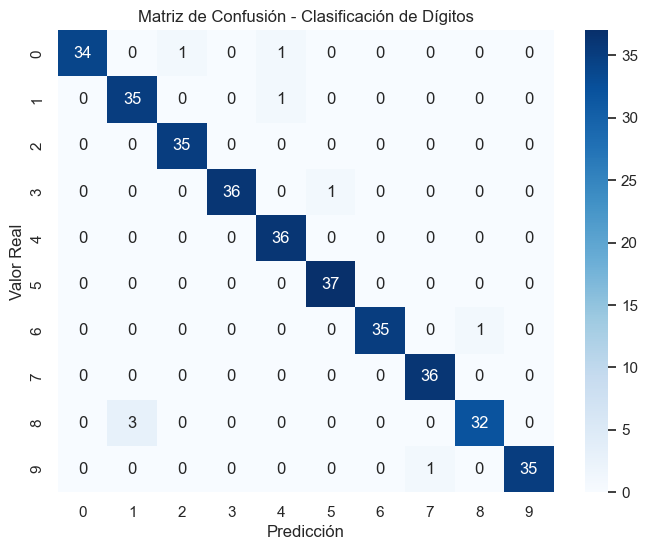

In [5]:
# Predicciones
y_pred_d_probs = model_digits.predict(X_test_d_norm)
y_pred_d_classes = np.argmax(y_pred_d_probs, axis=1)

# Matriz de Confusión
cm = confusion_matrix(y_test_d, y_pred_d_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.title('Matriz de Confusión - Clasificación de Dígitos')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

* Muestre un conjunto de métricas de desempeño (tanto en entrenamiento como en test), para determinar la efectividad de su clasificador. Muestre 5 ejemplos de imágenes bien clasificadas y 5 ejemplos de imágenes mal clasificadas.

Métricas en Entrenamiento -> Pérdida: 0.0214, Exactitud (Accuracy): 0.9951
Métricas en Prueba (Test) -> Pérdida: 0.1024, Exactitud (Accuracy): 0.9750

Reporte de Clasificación (Test):
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        36
           1       0.92      0.97      0.95        36
           2       0.97      1.00      0.99        35
           3       1.00      0.97      0.99        37
           4       0.95      1.00      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.97      0.91      0.94        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



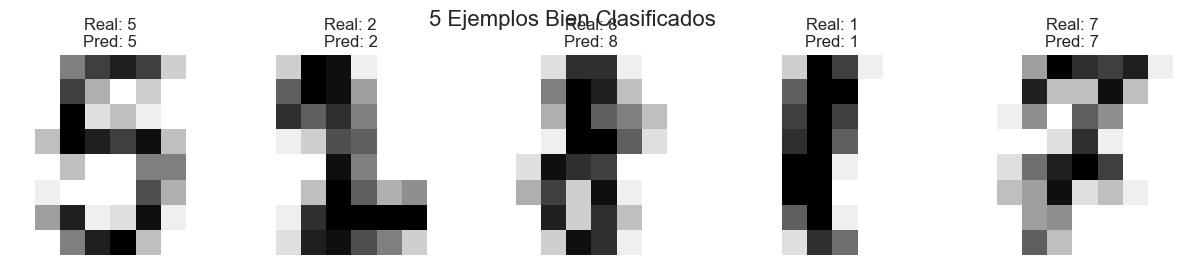

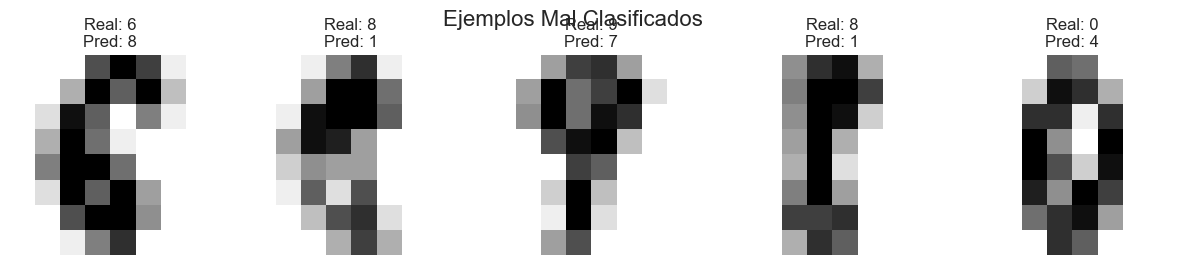

In [6]:
train_loss, train_acc = model_digits.evaluate(X_train_d_norm, y_train_d_cat, verbose=0)
test_loss, test_acc = model_digits.evaluate(X_test_d_norm, y_test_d_cat, verbose=0)

print(f"Métricas en Entrenamiento -> Pérdida: {train_loss:.4f}, Exactitud (Accuracy): {train_acc:.4f}")
print(f"Métricas en Prueba (Test) -> Pérdida: {test_loss:.4f}, Exactitud (Accuracy): {test_acc:.4f}\n")
print("Reporte de Clasificación (Test):\n", classification_report(y_test_d, y_pred_d_classes))

correct_indices = np.where(y_pred_d_classes == y_test_d)[0]
incorrect_indices = np.where(y_pred_d_classes != y_test_d)[0]

def plot_examples(indices, title):
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(title, fontsize=16)
    for i, ax in enumerate(axes):
        if i < len(indices):
            idx = indices[i]
            image = X_test_d[idx].reshape(8, 8)
            ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
            ax.set_title(f"Real: {y_test_d[idx]}\nPred: {y_pred_d_classes[idx]}")
        ax.axis('off')
    plt.show()
    
plot_examples(correct_indices[:5], "5 Ejemplos Bien Clasificados")

if len(incorrect_indices) > 0:
    plot_examples(incorrect_indices[:5], "Ejemplos Mal Clasificados")
else:
    print("¡Impresionante, el modelo no se ha equivocado en ninguna predicción!")

## Ejercicio 2: Regresión de Precios (Scikit-Learn california_housing)
Este ejercicio se centra en construir un modelo de regresión mediante una red neuronal densa.

**Dataset:** `sklearn.datasets.fetch_california_housing()`

**Objetivo:** Manejo de escalas heterogéneas y métricas de error continuo.

**Instrucciones:**
* Estandarizar los datos (Escalamiento Obligatorio). Usar StandardScaler en los datos de entrada. Sin esto, la red tardará demasiado en converger o los gradientes explotarán.

In [7]:
# 1. Carga de datos
housing = fetch_california_housing()
X_housing = housing.data
y_housing = housing.target

# 2. Partición de datos (Train/Test)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# 3. Estandarización de los datos
scaler = StandardScaler()
X_train_h_scaled = scaler.fit_transform(X_train_h)
X_test_h_scaled = scaler.transform(X_test_h)

**Explicación del Procedimiento y Transformaciones:**
* **Partición (Train/Test):** Se utilizó un 80% de los datos para entrenar y un 20% para validar (`test_size=0.2`). En problemas de regresión con un buen volumen de datos (más de 20,000 registros), esta proporción garantiza que el modelo tenga amplia información para ajustar sus pesos y suficientes datos inéditos para medir su error real.

* **Estandarización:** Se aplicó `StandardScaler` para que todas las variables de entrada tengan una media de 0 y una desviación estándar de 1. Esto es crítico en redes neuronales para regresión, ya que los atributos tienen escalas muy distintas (ej. edad de la casa vs. ingreso medio). Sin estandarización, los gradientes podrían explotar o la red tardaría demasiado en converger. El escalador se ajusta (`fit`) solo con los datos de entrenamiento para evitar el *data leakage* (fuga de información) desde el conjunto de prueba.

---

* Probar una red más profunda (ej. 3 capas: 64, 32, 16 o similar) dada la complejidad de los datos socioeconómicos. Justificar la elección de su arquitectura.

In [28]:
model_housing = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_h.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear') 
])

model_housing.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

**Justificación de la Arquitectura:**
* **Capas y Neuronas:** Se eligió una arquitectura más profunda de 3 capas ocultas (64, 32 y 16 neuronas). Los datos socioeconómicos y geográficos suelen tener relaciones no lineales y complejas entre sí. Una red más profunda permite extraer jerarquías de características más abstractas (ej. combinar latitud/longitud con ingresos para inferir zonas exclusivas).

* **Funciones de Activación:** Las capas ocultas usan **ReLU** para manejar la no linealidad. La capa de salida tiene **1 sola neurona** con activación **Lineal** (por defecto en `Dense` si no se especifica, pero explícita aquí por claridad), lo cual es obligatorio en problemas de regresión para poder predecir cualquier valor continuo, sin restricciones de rango.
---

* Elegir la función de pérdida apropiada (ej. MSE o MAE) y usar un optimizador Adam. Justifique la elección de sus hiper-parámetros.

In [9]:
model_housing.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='mse',
    metrics=['mae']
)

# Entrenamiento del modelo
history_housing = model_housing.fit(
    X_train_h_scaled, y_train_h,
    epochs=60,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/60
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6511 - mae: 0.5483 - val_loss: 0.4139 - val_mae: 0.4723
Epoch 2/60
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3655 - mae: 0.4293 - val_loss: 0.3833 - val_mae: 0.4416
Epoch 3/60
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3503 - mae: 0.4142 - val_loss: 0.3485 - val_mae: 0.4106
Epoch 4/60
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3895 - mae: 0.4083 - val_loss: 0.3417 - val_mae: 0.4031
Epoch 5/60
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3232 - mae: 0.3943 - val_loss: 0.3408 - val_mae: 0.3961
Epoch 6/60
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3114 - mae: 0.3856 - val_loss: 0.3357 - val_mae: 0.4143
Epoch 7/60
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3065 - mae: 0.3846 - val_loss: 0.3215 - val_mae: 0.3853
Epoch 8/60
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3012 - mae: 0.3791 - val_loss: 0.3497 - val_mae: 0.3903
Epoch 9/60
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

**Justificación de Hiper-parámetros:**
* **Función de pérdida:** Se utilizó el Error Cuadrático Medio (**MSE**). Es la función estándar para regresión, ya que penaliza de forma cuadrática los errores más grandes, obligando al modelo a evitar predicciones extremas que estén muy lejos del valor real.

* **Optimizador y Learning Rate:** Se usa **Adam** con una tasa de aprendizaje ligeramente mayor ($\alpha = 0.005$) para acelerar la convergencia inicial en este espacio de características estandarizado.

* **Epochs y Batch Size:** Se aumentó a 60 *epochs* y un *batch size* de 64. Al tener más de 20,000 registros, un batch size más grande aprovecha mejor la vectorización y acelera el entrenamiento, manteniendo una buena estimación del gradiente.

---

* Mostrar un Generar un Scatter-Plot de Predicciones vs. Valores Reales.

Muestre un conjunto de métricas de desempeño (tanto en entrenamiento como en test), para determinar la efectividad de su regresión. Elabore 3 ejemplos de predicción con su modelo de regresión para 3 observaciones nuevas (que no son parte del dataset).

516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step
--- Métricas de Entrenamiento ---
MSE: 0.2307
MAE: 0.3228
R2 Score: 0.8274

--- Métricas de Prueba (Test) ---
MSE: 0.2817
MAE: 0.3470
R2 Score: 0.7850



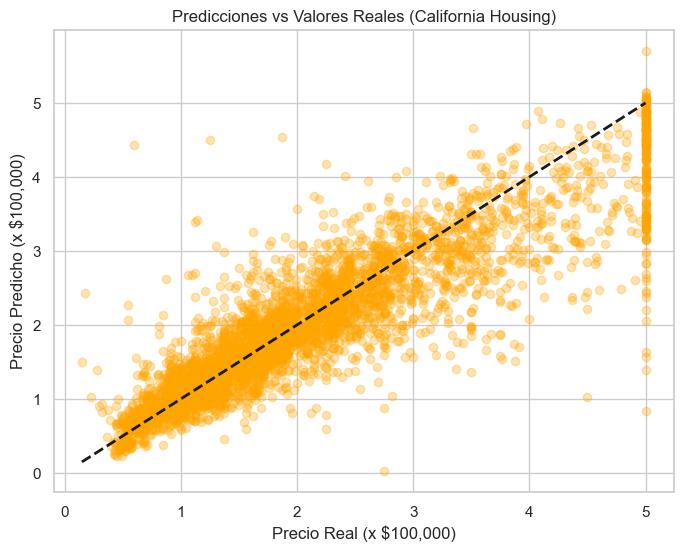

In [ ]:
y_pred_h_train = model_housing.predict(X_train_h_scaled)
y_pred_h_test = model_housing.predict(X_test_h_scaled)

print("--- Métricas de Entrenamiento ---")
print(f"MSE: {mean_squared_error(y_train_h, y_pred_h_train):.4f}")
print(f"MAE: {mean_absolute_error(y_train_h, y_pred_h_train):.4f}")
print(f"R2 Score: {r2_score(y_train_h, y_pred_h_train):.4f}\n")

print("--- Métricas de Prueba (Test) ---")
print(f"MSE: {mean_squared_error(y_test_h, y_pred_h_test):.4f}")
print(f"MAE: {mean_absolute_error(y_test_h, y_pred_h_test):.4f}")
print(f"R2 Score: {r2_score(y_test_h, y_pred_h_test):.4f}\n")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_h, y_pred_h_test, alpha=0.3, color='orange')
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'k--', lw=2)
plt.title('Predicciones vs Valores Reales (California Housing)')
plt.xlabel('Precio Real (x $100,000)')
plt.ylabel('Precio Predicho (x $100,000)')
plt.show()

In [13]:
nuevas_casas = np.array([
    [5.0, 25.0, 6.0, 1.0, 1000.0, 3.0, 37.5, -122.0],
    [1.5, 40.0, 3.0, 1.2, 500.0, 4.0, 36.0, -119.0],
    [8.0, 10.0, 8.0, 1.5, 2000.0, 2.5, 34.0, -118.0] 
])

nuevas_casas_scaled = scaler.transform(nuevas_casas)
predicciones_nuevas = model_housing.predict(nuevas_casas_scaled)

print("\n--- Resultados de las Nuevas Predicciones ---")
print("Recordatorio: Los valores originales de 'target' están en cientos de miles de dólares.\n")

perfiles = [
    "Casa estándar (Zona Central)", 
    "Casa antigua (Ingreso Bajo)", 
    "Casa nueva y amplia (Ingreso Alto)"
]

for i, pred in enumerate(predicciones_nuevas):
    precio_estimado = pred[0] * 100000
    print(f"Perfil {i+1} - {perfiles[i]}:")
    print(f" -> Valor predicho por la red: ${precio_estimado:,.2f}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

--- Resultados de las Nuevas Predicciones ---
Recordatorio: Los valores originales de 'target' están en cientos de miles de dólares.

Perfil 1 - Casa estándar (Zona Central):
 -> Valor predicho por la red: $256,125.09

Perfil 2 - Casa antigua (Ingreso Bajo):
 -> Valor predicho por la red: $26,365.41

Perfil 3 - Casa nueva y amplia (Ingreso Alto):
 -> Valor predicho por la red: $449,621.97

